In [2]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [3]:
model = joblib.load("model_artifacts/final_fraud_model.pkl")

x_test = joblib.load("processed_data/x_test_scaled.pkl")
y_test = joblib.load("processed_data/y_test.pkl")

selected_features = joblib.load("model_artifacts/selected_features.pkl")

print("Model and test data loaded successfully")

Model and test data loaded successfully


In [4]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

print("Predictions completed")

Predictions completed


In [5]:
# final metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.99817
Precision: 0.9806094182825484
Recall   : 0.9735
F1 Score : 0.9770417764395936
ROC-AUC  : 0.99874395703125


In [6]:
# classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     96000
           1       0.98      0.97      0.98      4000

    accuracy                           1.00    100000
   macro avg       0.99      0.99      0.99    100000
weighted avg       1.00      1.00      1.00    100000



Text(45.722222222222214, 0.5, 'Actual')

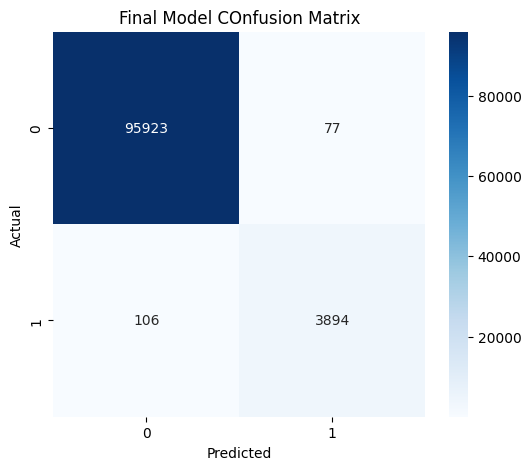

In [7]:
# confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm, 
    annot=True,
    fmt="d",
    cmap="Blues"
    )

plt.title("Final Model COnfusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

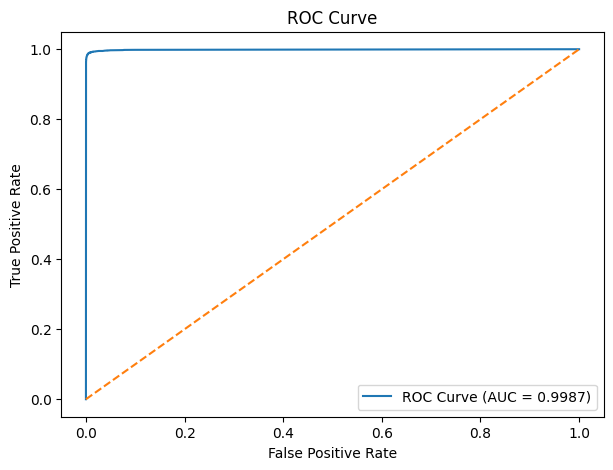

In [8]:
# ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [9]:
# Feature importance

importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
14,Risk_Score,0.312528
13,Transaction_Velocity,0.193457
12,Account_Age_Days,0.132613
6,Failed_Login_Attempts,0.129432
8,Unusual_Location,0.061574
7,Previous_Transactions_24H,0.040789
11,New_Device_Login,0.039907
5,International_Transaction,0.035184
1,Amount,0.020761
9,VPN_Used,0.011433


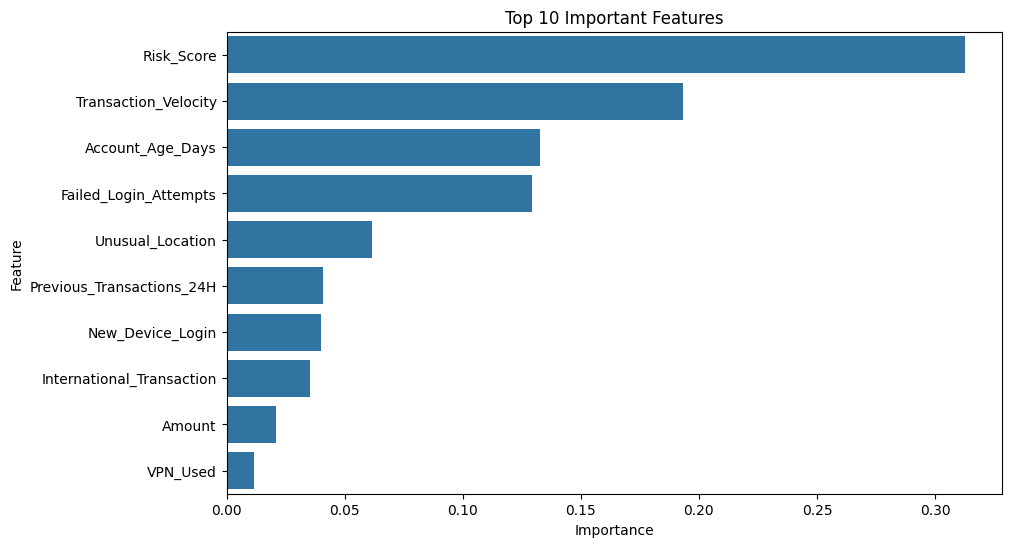

In [10]:
# feature importance graph

plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [11]:
importance_df.to_csv(
    "model_artifacts/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully")

Feature importance saved successfully


In [12]:
selected_features = joblib.load(
    "model_artifacts/selected_features.pkl"
)

print(selected_features)

['Day_Of_Week', 'Amount', 'Merchant_Category', 'City', 'Country', 'International_Transaction', 'Failed_Login_Attempts', 'Previous_Transactions_24H', 'Unusual_Location', 'VPN_Used', 'Multiple_Cards_Used', 'New_Device_Login', 'Account_Age_Days', 'Transaction_Velocity', 'Risk_Score']
